# EEG Data Preprocessing from EDF File

This notebook demonstrates how to preprocess EEG data loaded from an EDF file. Steps include loading the data, applying a bandpass filter, removing DC offset, and visualizing the results.

## 1. Import Required Libraries

In [ ]:
%pip install mne

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import mne

## 2. Load EEG Data from EDF File

In [6]:
import os
import mne

# Set folder to the resting_state subject EEG directory (relative to workspace)
folder = os.path.join(os.getcwd(), 'resting_state', 'sub-001', 'eeg')
print('Looking in folder:', folder)

# Find all .edf files in the folder and print their absolute paths
edf_files = [f for f in os.listdir(folder) if f.lower().endswith('.edf')]
if not edf_files:
    raise FileNotFoundError(f"No .edf file found in the folder: {folder}")
for f in edf_files:
    abs_path = os.path.abspath(os.path.join(folder, f))
    print("EDF found:", abs_path)

# Use the first .edf file found
edf_path = os.path.abspath(os.path.join(folder, edf_files[0]))
print("Using EDF file:", edf_path)

# Check if the file really exists before loading
if not os.path.exists(edf_path):
    raise FileNotFoundError(f"File does not exist: {edf_path}")

raw = mne.io.read_raw_edf(edf_path, preload=True)
eeg_data = raw.get_data()  # shape: (n_channels, n_samples)
fs = int(raw.info['sfreq'])  # Sampling frequency

# Select a channel for processing (e.g., first channel)
channel_idx = 0  # Change as needed
eeg_channel = eeg_data[channel_idx]

t = np.arange(eeg_channel.size) / fs

print(f"Loaded EEG data with {eeg_data.shape[0]} channels and {eeg_data.shape[1]} samples. Sampling rate: {fs} Hz")

Looking in folder: /workspaces/Dreamers/resting_state/sub-001/eeg
EDF found: /workspaces/Dreamers/resting_state/sub-001/eeg/sub-001_ses-t1_task-resteyesc_eeg.edf
Using EDF file: /workspaces/Dreamers/resting_state/sub-001/eeg/sub-001_ses-t1_task-resteyesc_eeg.edf
Extracting EDF parameters from /workspaces/Dreamers/resting_state/sub-001/eeg/sub-001_ses-t1_task-resteyesc_eeg.edf...
EDF file detected
Setting channel info structure...
Extracting EDF parameters from /workspaces/Dreamers/resting_state/sub-001/eeg/sub-001_ses-t1_task-resteyesc_eeg.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Creating raw.info structure...
Reading 0 ... 245759  =      0.000 ...   239.999 secs...
Reading 0 ... 245759  =      0.000 ...   239.999 secs...
Loaded EEG data with 64 channels and 245760 samples. Sampling rate: 1024 Hz
Loaded EEG data with 64 channels and 245760 samples. Sampling rate: 1024 Hz


In [7]:
import os
print(os.listdir())

['.git', 'README.md', 'lucid_state_donders', 'preprocess_eeg_edf.ipynb', 'test.py', 'resting_state']


Extracting EDF parameters from /workspaces/Dreamers/resting_state/sub-001/eeg/sub-001_ses-t1_task-resteyesc_eeg.edf...
EDF file detected
Setting channel info structure...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 245759  =      0.000 ...   239.999 secs...
Creating raw.info structure...
Reading 0 ... 245759  =      0.000 ...   239.999 secs...
Using matplotlib as 2D backend.
Using matplotlib as 2D backend.


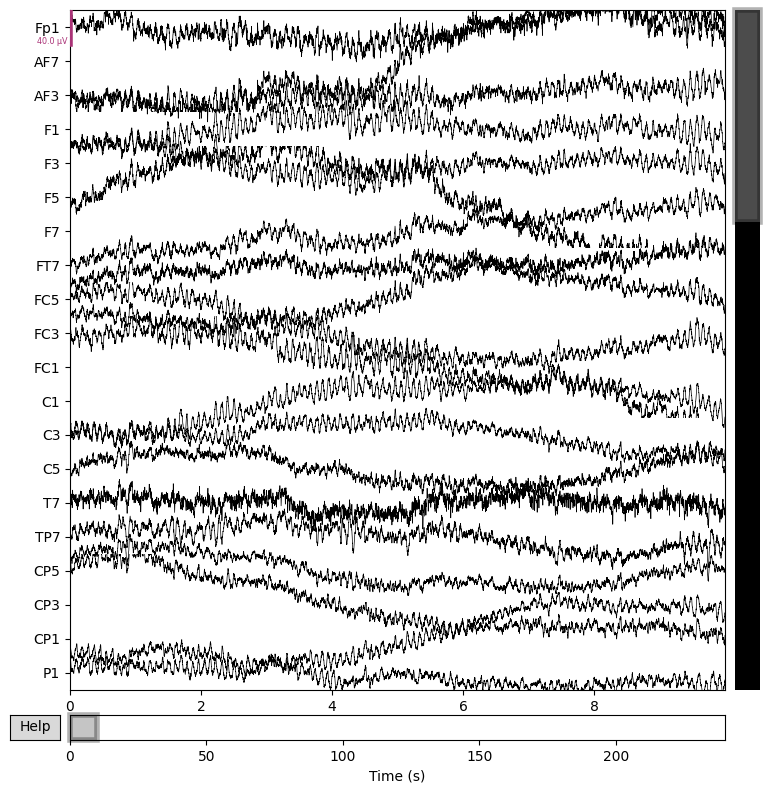

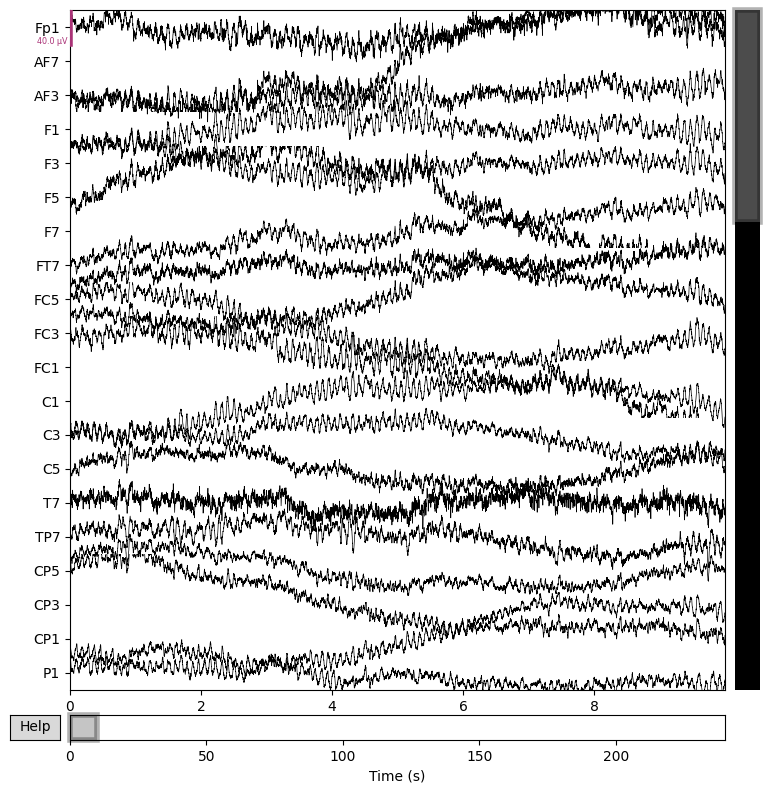

In [ ]:
# Load and plot the raw EEG data from the specified EDF file 
raw = mne.io.read_raw_edf("resting_state/sub-001/eeg/sub-001_ses-t1_task-resteyesc_eeg.edf", preload=True)
raw.plot()

## 3. Bandpass Filter the EEG Data

In [8]:
def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = signal.butter(order, [low, high], btype='band')
    return signal.filtfilt(b, a, data)

filtered_eeg = bandpass_filter(eeg_channel, 0.5, 40, fs)

## 4. Remove DC Offset

In [9]:
filtered_eeg = filtered_eeg - np.mean(filtered_eeg)

## 5. Plot Raw vs Filtered EEG Data

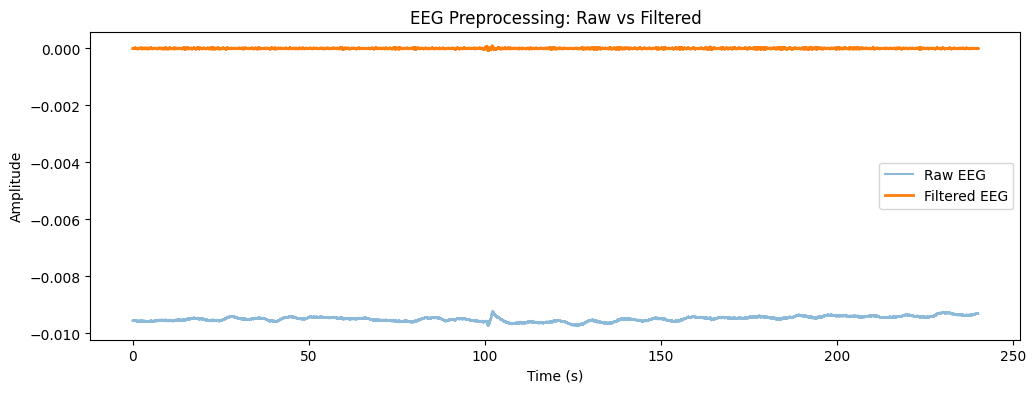

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(t, eeg_channel, label='Raw EEG', alpha=0.5)
plt.plot(t, filtered_eeg, label='Filtered EEG', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.title('EEG Preprocessing: Raw vs Filtered')
plt.show()